In [ ]:
from functions import generate_H, generate_D, generate_F, compute_costs, accumulate_traces, pick_direction, gradient_analysis
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

In [2]:
# B = 36 # Number of visual bins, evenly distributed around the agent
# scale = 50  # length of one side of the H map in meters
# resolution = 10 # simulated points per meter 
# sigma = 40 # major slope in degrees
# noise_scale = 0 # Noise applied to H(x,y,t=0)

# # Generate H 
# x, y, H0, size, offsets = generate_H(scale, resolution, sigma, noise_scale, plot=False)

# # Randomly initiate agents 
# N = 3 # number of agents 
# agent_pos = size*np.random.rand(2,N)

# # Critical parameters
# beta = 50 # Energy landscape sensitivity
# alpha = -0.1 #The depth of the agent's footprint. How quickly the environment erodes. 
# delta = 0.5*resolution #Footprint interval.
# eta = 0.5*resolution #resolution
# L = 10*resolution

# # Generate the footprint map
# r_F = 1*resolution
# F = generate_F(r_F) #radius*2)

# # Initialize the depletion layer
# R = np.ones([size, size])

# # Generate the depletion map
# r_D = 2*resolution
# D = generate_D(r_D) #radius*2)
# gamma = -1 # resource depletion strength
# mu = 0.1 # resource regrowth rate
# w_v = 8.25 # vertical motion cost scalar
# w_h = 0.95 # horizontal motion cost scalar 

# max_steps = 50000
# num_steps = 0
# plt_interval = max_steps//20
# max_erosion = resolution*1.5
# abs_erosion = 0 
# save_interval = 10
# abs_erosion = 0 
# frame = 0

# # Create the enviroment for modification (gradient_layer)
# H = H0.copy()

# omega = 2*resolution # gradient analysis window size 

# # store entropy as a test
# mean_entropy = []
# test_H = []

In [3]:
# w_vs = np.linspace(0.95, 15, 40)
# w_vs = np.append(w_vs, 8.25)
# w_h = 0.95

# steps = np.zeros(len(w_vs))
# ratio = w_vs / w_h
# np.save(f'wvwh_sweep/ratio.npy', ratio)
# entropys = np.zeros(len(w_vs))
# coherence = np.zeros(len(w_vs))

# for beta in [25, 50]:

#     for i, w_v in enumerate(w_vs): 
#         # reinitialize necessary parameters
#         num_steps = 0
#         abs_erosion = 0
#         mean_entropy = []
#         H = H0.copy()
#         R = np.ones([size, size])
#         agent_pos = size*np.random.rand(2,N)
        
#         while (num_steps <= max_steps) and (abs_erosion <= max_erosion):

#             R += mu
#             R[R > 1] = 1

#             for j in range(N): 
#                 # Compute costs along potential paths     
#                 angles_mesh, radial_mesh, gradient, depletion = compute_costs(agent_pos[:,j], B, delta, L, H, R, size, offsets, resolution)
#                 # Pick a new direction and update agent position
#                 agent_pos[:,j], line, angle, entropy = pick_direction(agent_pos[:,j], beta, angles_mesh, radial_mesh, gradient, depletion, w_h, w_v, delta, size)
#                 mean_entropy.append(np.mean(entropy))
#                 # Update gradient layer 
#                 H, _ = accumulate_traces(H, F, line, alpha, eta)    
#                 deviation = H0 - H
#                 abs_erosion = np.max(deviation) - np.min(deviation)
                
#                 # Update resource layer
#                 R, _ = accumulate_traces(R, D, line, gamma, 0)
#                 R[R < 0] = 0
                
#             num_steps += 1
#             test_H.append(H[:, size//2].copy())
        
#         _, mean_gradient, mean_coherence = gradient_analysis(deviation, omega)
        
#         steps[i] = num_steps
#         coherence[i] = mean_coherence
    
#         np.save(f'SIfig03/steps_{beta}.npy', steps)
#         np.save(f'SIfig03/coherence_{beta}.npy', coherence)
        
#         # Plot an update of terrain and resource erosion
#         fig, axs = plt.subplots(ncols=2, figsize=(5,10))
#         axs[0].imshow(deviation - np.min(deviation), origin='lower', cmap='jet', extent=(0, scale, 0, scale))
#         axs[0].set_title(f't={num_steps}, beta={beta}')
#         axs[1].imshow(R, origin='lower', cmap='Greens', extent=(0, scale, 0, scale))
#         axs[1].set_title(f'sigma={sigma}, ratio={ratio[i]}, N={N}')
#         plt.show()
        

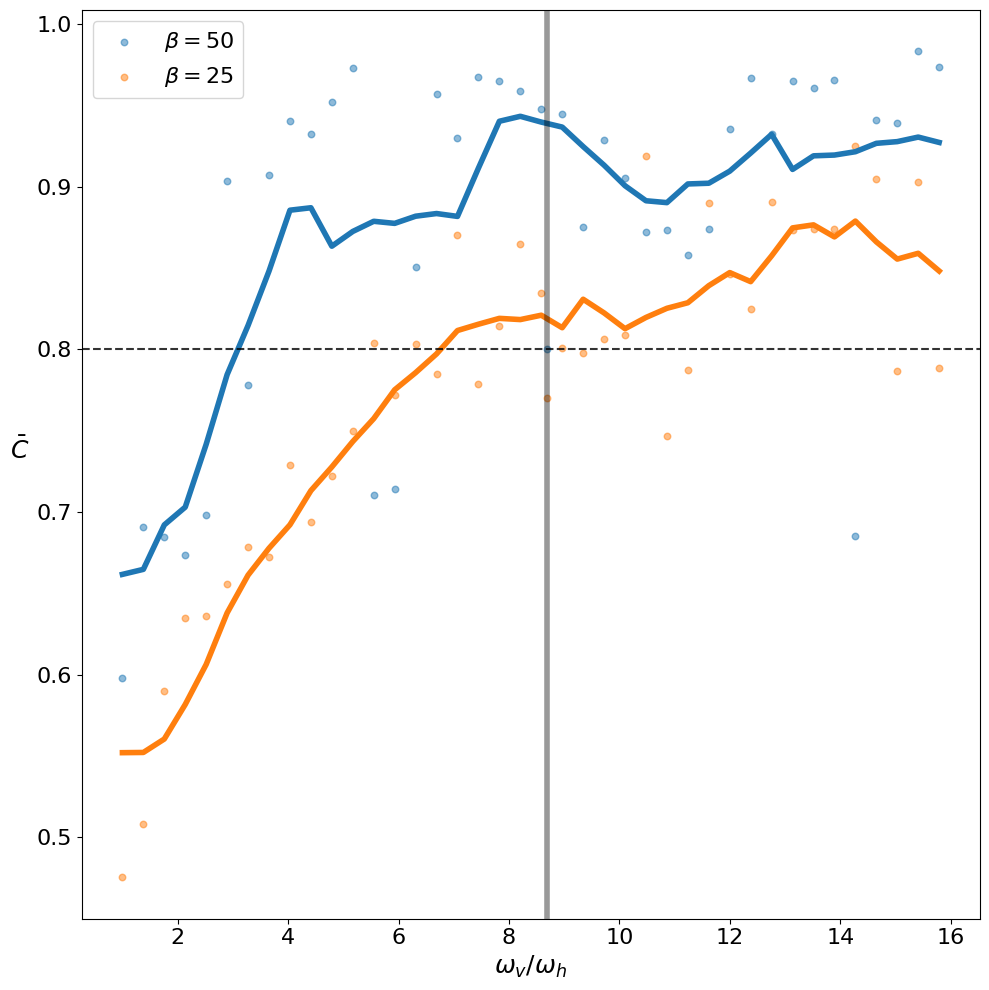

In [4]:

ratios = np.load('SIfig03/ratio.npy')
fig = plt.figure(figsize=(10,10))

# β=50
coh50 = np.load('SIfig03/coherence_50.npy')
plt.scatter(ratios, coh50, s=22, alpha=0.5, color='#1f77b4', label=r'$\beta=50$')
smooth50 = uniform_filter1d(coh50[:-1], size=8)   # window size = 7 points
plt.plot(ratios[:-1], smooth50, lw=4, alpha=1, color='#1f77b4')

# β=25
coh25 = np.load('SIfig03/coherence_25.npy')
plt.scatter(ratios, coh25, s=22, alpha=0.5, color='#ff7f0e', label=r'$\beta=25$')
smooth25 = uniform_filter1d(coh25[:-1], size=8)
plt.plot(ratios[:-1], smooth25, lw=4, alpha=1, color='#ff7f0e')

# reference lines
plt.axvline(8.25/0.95, c='k', ls='-', alpha=0.4, lw=4)
plt.axhline(0.8, c='k', ls='--', alpha=0.8)
#plt.text(12, 0.81, r'$\bar{C} >= 0.8$')

plt.xlabel(r'$\omega_v / \omega_h$', fontsize=18)
plt.ylabel(r'$\bar{C}$', rotation=0, labelpad=12, fontsize=18)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

#plt.savefig('Figures/wv_wh.png', transparent=True, bbox_inches='tight')
